In [2]:
import pandas as pd
import numpy as np

In [3]:
customers = pd.read_csv("/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/customers.csv")
articles = pd.read_csv("/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/articles.csv")
transactions = pd.read_csv("/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/transactions_train.csv")

print(customers.shape)
print(articles.shape)
print(transactions.shape)

(1371980, 7)
(105542, 25)
(31788324, 5)


In [4]:
customers.head()


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [5]:
articles.head()


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [6]:
customers.isnull().sum()

customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

In [7]:
articles.isnull().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [10]:
customers.drop(columns=['FN'], inplace=True)
customers.drop(columns=["Active"], inplace=True)

customers["club_member_status"] = (
    customers["club_member_status"]
    .fillna("UNKNOWN"))

customers["fashion_news_frequency"] = (
    customers["fashion_news_frequency"]
    .fillna("NONE"))



KeyError: "['FN'] not found in axis"

In [11]:
# Safe drop — won't crash if column doesn't exist
cols_to_drop = ['FN', 'Active']
customers.drop(columns=[c for c in cols_to_drop if c in customers.columns], inplace=True)

customers["club_member_status"] = (
    customers["club_member_status"]
    .fillna("UNKNOWN"))

customers["fashion_news_frequency"] = (
    customers["fashion_news_frequency"]
    .fillna("NONE"))

print("Remaining columns:", list(customers.columns))

Remaining columns: ['customer_id', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']


<Axes: >

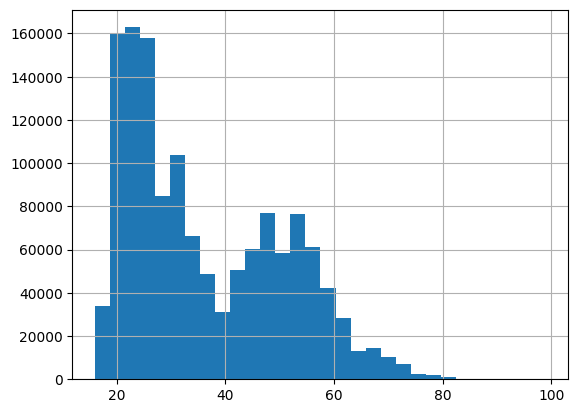

In [12]:
customers["age"].hist(bins=30)

In [14]:
customers["age"] = customers["age"].fillna(
    customers["age"].median()
)

In [15]:
customers["club_member_status"].value_counts(dropna=False)


club_member_status
ACTIVE        1272491
PRE-CREATE      92960
UNKNOWN          6062
LEFT CLUB         467
Name: count, dtype: int64

In [16]:
customers["fashion_news_frequency"].value_counts(dropna=False)


fashion_news_frequency
NONE         893722
Regularly    477416
Monthly         842
Name: count, dtype: int64

In [17]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   price             float64
 4   sales_channel_id  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.2+ GB


In [18]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [19]:
transactions.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

In [20]:
transactions["t_dat"]=pd.to_datetime(transactions["t_dat"])

In [21]:
print(transactions["t_dat"])

0          2018-09-20
1          2018-09-20
2          2018-09-20
3          2018-09-20
4          2018-09-20
              ...    
31788319   2020-09-22
31788320   2020-09-22
31788321   2020-09-22
31788322   2020-09-22
31788323   2020-09-22
Name: t_dat, Length: 31788324, dtype: datetime64[ns]


In [22]:
purchase_count = (
    transactions
    .groupby("customer_id")
    .size()
    .reset_index(name="purchase_count")
)

In [23]:
avg_spend =(
    transactions
    .groupby("customer_id")
    ["price"].mean()
    .reset_index(name ="avg_spend")
)

In [24]:
total_spend =(
    transactions
    .groupby("customer_id")
    ["price"].sum()
    .reset_index(name="total_spend")
)

In [25]:
last_purchase =(
    transactions
    .groupby("customer_id")
    ["t_dat"].max()
    .reset_index(name="last_purchase")
)



In [26]:
max_date = transactions["t_dat"].max()
last_purchase["days_since_last_purchase"] = (
    max_date - last_purchase["last_purchase"]
).dt.days

In [27]:
user_features=purchase_count.merge(
    avg_spend,
    on="customer_id"
)

In [28]:
user_features= user_features.merge(
    total_spend,
    on="customer_id"
)

In [29]:
user_features=user_features.merge(
    last_purchase[
   [ "customer_id",
    "days_since_last_purchase"]
    ],
    on="customer_id"
)

In [30]:
print(user_features.columns)

Index(['customer_id', 'purchase_count', 'avg_spend', 'total_spend',
       'days_since_last_purchase'],
      dtype='object')


In [31]:
user_features.head()

,customer_id,purchase_count,avg_spend,total_spend,days_since_last_purchase
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,21,0.030904,0.648983,17
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,86,0.030255,2.601932,76
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,18,0.039154,0.704780,7
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2,0.030492,0.060983,471
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,13,0.036130,0.469695,41


In [64]:
#(user_features["days_since_last_purchase_x"]==user_features["days_since_last_purchase_y"]).all()

In [34]:
# Check current columns - no duplicates this time, safe to continue
print("user_features columns:", list(user_features.columns))
print("Shape:", user_features.shape)

user_features columns: ['customer_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase']
Shape: (1362281, 5)


In [65]:
#user_features.drop(
 #   columns=["days_since_last_purchase_y"],
 #   inplace=True
#)

#user_features.rename(
#    columns={
 #       "days_since_last_purchase_x":
 #       "days_since_last_purchase"
 #   },
 #   inplace=True
 #   )

In [36]:
# Safe cleanup — handles both cases (with or without _x/_y duplicates)
if "days_since_last_purchase_y" in user_features.columns:
    user_features.drop(columns=["days_since_last_purchase_y"], inplace=True)

if "days_since_last_purchase_x" in user_features.columns:
    user_features.rename(columns={
        "days_since_last_purchase_x": "days_since_last_purchase"
    }, inplace=True)

print("Columns now:", list(user_features.columns))

Columns now: ['customer_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase']


In [37]:
user_features.head()

,customer_id,purchase_count,avg_spend,total_spend,days_since_last_purchase
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,21,0.030904,0.648983,17
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,86,0.030255,2.601932,76
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,18,0.039154,0.704780,7
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2,0.030492,0.060983,471
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,13,0.036130,0.469695,41


In [39]:
#club_member_status          6062
#fashion_news_frequency     16011
#age      

In [40]:
user_features = user_features.merge(
    customers[
   [ "club_member_status",
    "customer_id",
    "fashion_news_frequency",
    "age"]
    ],
    on="customer_id",
    how="left"
)

In [41]:
user_features.isnull().sum()

customer_id                 0
purchase_count              0
avg_spend                   0
total_spend                 0
days_since_last_purchase    0
club_member_status          0
fashion_news_frequency      0
age                         0
dtype: int64

In [43]:
user_features["age_group"] = pd.cut(
    user_features["age"],
    bins=[0,18,30,50,60],
    labels=["Teen",
            "Adults",
            "Middle Aged",
            "Senior Citizens"]
)

In [44]:
user_features["age_group"].value_counts()

age_group
Adults             600966
Middle Aged        440969
Senior Citizens    208544
Teen                33247
Name: count, dtype: int64

In [45]:
item_features = (
    transactions
    .groupby("article_id")
    .agg(
        purchase_count=("customer_id","count"),
        avg_price=("price","mean")
    )
        .reset_index()       
)

In [46]:
item_features = item_features.merge(
    articles[
    ["article_id",
     "product_type_name",
     "product_group_name",
     "garment_group_name",
     "colour_group_name"
    ]
    ],
    on="article_id",
    how="left"
)

In [47]:
item_features.head()

,article_id,purchase_count,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
0,108775015,10841,0.008142,Vest top,Garment Upper body,Jersey Basic,Black
1,108775044,7250,0.008114,Vest top,Garment Upper body,Jersey Basic,White
2,108775051,215,0.004980,Vest top,Garment Upper body,Jersey Basic,Off White
3,110065001,1044,0.020219,Bra,Underwear,"Under-, Nightwear",Black
4,110065002,539,0.018205,Bra,Underwear,"Under-, Nightwear",White


In [48]:
item_features.sort_values(
    by="purchase_count",
    ascending=False).head(10)
    

,article_id,purchase_count,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
53832,706016001,50287,0.032448,Trousers,Garment Lower body,Trousers,Black
53833,706016002,35043,0.032426,Trousers,Garment Lower body,Trousers,Light Blue
1711,372860001,31718,0.012958,Socks,Socks & Tights,Socks and Tights,Black
24808,610776002,30199,0.008083,T-shirt,Garment Upper body,Jersey Basic,Black
70124,759871002,26329,0.005605,Vest top,Garment Upper body,Jersey Basic,Black
3706,464297007,25025,0.016192,Underwear bottom,Underwear,"Under-, Nightwear",Black
1712,372860002,24458,0.012155,Socks,Socks & Tights,Socks and Tights,White
24807,610776001,22451,0.008079,T-shirt,Garment Upper body,Jersey Basic,White
2233,399223001,22236,0.030873,Trousers,Garment Lower body,Trousers Denim,Black
53834,706016003,21241,0.032588,Trousers,Garment Lower body,Trousers,Dark Blue


In [49]:
final_data = transactions.merge(
    user_features,
    on="customer_id",
    how="left"
)

final_data = final_data.merge(
    item_features,
    on="article_id",
    how="left")


In [50]:
final_data.head()

,t_dat,customer_id,article_id,price,sales_channel_id,purchase_count_x,avg_spend,total_spend,days_since_last_purchase,club_member_status,fashion_news_frequency,age,age_group,purchase_count_y,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,18,0.039154,0.70478,7,ACTIVE,NONE,24.0,Adults,633,0.045512,Underwear body,Underwear,"Under-, Nightwear",Black
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,18,0.039154,0.70478,7,ACTIVE,NONE,24.0,Adults,434,0.024343,Bra,Underwear,"Under-, Nightwear",Light Pink
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,120,0.031863,3.82361,132,ACTIVE,Regularly,32.0,Middle Aged,42,0.014834,Sweater,Garment Upper body,Knitwear,Pink
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,120,0.031863,3.82361,132,ACTIVE,Regularly,32.0,Middle Aged,1836,0.021812,Sweater,Garment Upper body,Special Offers,Pink
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,120,0.031863,3.82361,132,ACTIVE,Regularly,32.0,Middle Aged,1792,0.021569,Sweater,Garment Upper body,Special Offers,Dark Green


In [51]:
(final_data["purchase_count_x"]==final_data["purchase_count_y"]).all()

np.False_

In [52]:
user_features.to_csv(
    "user_features.csv",
    index=False
)

item_features.to_csv(
    "item_features.csv",
    index=False
)

final_data.to_csv(
    "final_data.csv",
    index=False
)

In [53]:
import pandas as pd
import numpy as np
import json
import os

print('Libraries loaded successfully')

Libraries loaded successfully


In [54]:
user_features  = pd.read_csv('user_features.csv')
item_features  = pd.read_csv('item_features.csv')
final_data     = pd.read_csv('final_data.csv')

print('user_features shape :', user_features.shape)
print('item_features shape :', item_features.shape)
print('final_data shape    :', final_data.shape)
print()
print('user_features columns:', list(user_features.columns))
print('item_features columns:', list(item_features.columns))

user_features shape : (1362281, 9)
item_features shape : (104547, 7)
final_data shape    : (31788324, 19)

user_features columns: ['customer_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group']
item_features columns: ['article_id', 'purchase_count', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']


In [55]:
# Check for duplicate suffix columns left from the merge
dup_cols = [c for c in final_data.columns if c.endswith('_x') or c.endswith('_y')]
print('Duplicate-suffix columns found:', dup_cols)

# Drop the _y versions; rename _x -> clean name
for col in dup_cols:
    if col.endswith('_y'):
        final_data.drop(columns=[col], inplace=True)
    elif col.endswith('_x'):
        clean_name = col[:-2]  # strip '_x'
        final_data.rename(columns={col: clean_name}, inplace=True)

print('Columns after cleanup:', list(final_data.columns))

Duplicate-suffix columns found: ['purchase_count_x', 'purchase_count_y']
Columns after cleanup: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']


In [56]:
# --- Categorical vocabularies (unique values the embedding layer needs to know) ---

club_member_vocab = sorted(user_features['club_member_status'].dropna().unique().tolist())
news_freq_vocab   = sorted(user_features['fashion_news_frequency'].dropna().unique().tolist())
age_group_vocab   = ['Teen', 'Adults', 'Middle Aged', 'Senior Citizens']  # ordered

print('club_member_status vocab :', club_member_vocab)
print('fashion_news_frequency vocab:', news_freq_vocab)
print('age_group vocab          :', age_group_vocab)

club_member_status vocab : ['ACTIVE', 'LEFT CLUB', 'PRE-CREATE', 'UNKNOWN']
fashion_news_frequency vocab: ['Monthly', 'NONE', 'Regularly']
age_group vocab          : ['Teen', 'Adults', 'Middle Aged', 'Senior Citizens']


In [57]:
# --- Numerical feature ranges (for normalisation in the model) ---

user_num_stats = user_features[[
    'purchase_count',
    'avg_spend',
    'total_spend',
    'days_since_last_purchase',
    'age'
]].agg(['min', 'max', 'mean', 'std'])

print('\nUser numerical feature stats:')
print(user_num_stats.round(3))


User numerical feature stats:
      purchase_count  avg_spend  total_spend  days_since_last_purchase     age
min            1.000      0.001        0.001                     0.000  16.000
max         1895.000      0.507       57.676                   733.000  99.000
mean          23.335      0.029        0.649                   235.148  36.345
std           39.242      0.014        1.198                   221.119  14.231


In [58]:
# --- Customer ID vocabulary (needed by the Query Tower embedding layer) ---

customer_id_vocab = user_features['customer_id'].unique().tolist()
print(f'Total unique customers : {len(customer_id_vocab):,}')
print('Sample customer IDs    :', customer_id_vocab[:3])

Total unique customers : 1,362,281
Sample customer IDs    : ['00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657', '0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa', '000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318']


In [59]:
# --- Categorical vocabularies for item features ---

product_type_vocab   = sorted(item_features['product_type_name'].dropna().unique().tolist())
product_group_vocab  = sorted(item_features['product_group_name'].dropna().unique().tolist())
garment_group_vocab  = sorted(item_features['garment_group_name'].dropna().unique().tolist())
colour_group_vocab   = sorted(item_features['colour_group_name'].dropna().unique().tolist())

print(f'product_type_name  : {len(product_type_vocab)} unique values')
print(f'product_group_name : {len(product_group_vocab)} unique values')
print(f'garment_group_name : {len(garment_group_vocab)} unique values')
print(f'colour_group_name  : {len(colour_group_vocab)} unique values')

product_type_name  : 130 unique values
product_group_name : 19 unique values
garment_group_name : 21 unique values
colour_group_name  : 50 unique values


In [60]:
# --- Numerical feature ranges for items ---

item_num_stats = item_features[['purchase_count', 'avg_price']].agg(['min', 'max', 'mean', 'std'])

print('Item numerical feature stats:')
print(item_num_stats.round(4))

Item numerical feature stats:
      purchase_count  avg_price
min           1.0000     0.0004
max       50287.0000     0.5068
mean        304.0577     0.0288
std         791.2661     0.0258


In [61]:
# --- Article ID vocabulary (needed by the Candidate Tower embedding layer) ---

article_id_vocab = item_features['article_id'].astype(str).unique().tolist()
print(f'Total unique articles : {len(article_id_vocab):,}')
print('Sample article IDs   :', article_id_vocab[:3])

Total unique articles : 104,547
Sample article IDs   : ['108775015', '108775044', '108775051']


**Save all vocabularies to JSON ( Week 2 model will load these)**

In [62]:
os.makedirs('vocabularies', exist_ok=True)

# --- User vocabularies ---
user_vocab = {
    'customer_id'             : customer_id_vocab,
    'club_member_status'      : club_member_vocab,
    'fashion_news_frequency'  : news_freq_vocab,
    'age_group'               : age_group_vocab,
    'numerical_stats'         : user_num_stats.to_dict()
}

with open('vocabularies/user_vocab.json', 'w') as f:
    json.dump(user_vocab, f, indent=2)

# --- Item vocabularies ---
item_vocab = {
    'article_id'         : article_id_vocab,
    'product_type_name'  : product_type_vocab,
    'product_group_name' : product_group_vocab,
    'garment_group_name' : garment_group_vocab,
    'colour_group_name'  : colour_group_vocab,
    'numerical_stats'    : item_num_stats.to_dict()
}

with open('vocabularies/item_vocab.json', 'w') as f:
    json.dump(item_vocab, f, indent=2)

print('Saved: vocabularies/user_vocab.json')
print('Saved: vocabularies/item_vocab.json')

Saved: vocabularies/user_vocab.json
Saved: vocabularies/item_vocab.json


In [63]:
print('========== VOCABULARY SUMMARY ==========')
print()
print('USER (Query Tower inputs)')
print(f'  customer_id vocab size     : {len(customer_id_vocab):>8,}')
print(f'  club_member_status         : {len(club_member_vocab):>8} values')
print(f'  fashion_news_frequency     : {len(news_freq_vocab):>8} values')
print(f'  age_group                  : {len(age_group_vocab):>8} values')
print(f'  numerical features         :        5  (purchase_count, avg_spend, total_spend, days_since_last_purchase, age)')
print()
print('ITEM (Candidate Tower inputs)')
print(f'  article_id vocab size      : {len(article_id_vocab):>8,}')
print(f'  product_type_name          : {len(product_type_vocab):>8} values')
print(f'  product_group_name         : {len(product_group_vocab):>8} values')
print(f'  garment_group_name         : {len(garment_group_vocab):>8} values')
print(f'  colour_group_name          : {len(colour_group_vocab):>8} values')
print(f'  numerical features         :        2  (purchase_count, avg_price)')
print()
print('Week 2 is ready to begin — load vocabularies/user_vocab.json & item_vocab.json')

========== VOCABULARY SUMMARY ==========

USER (Query Tower inputs)
  customer_id vocab size     : 1,362,281
  club_member_status         :        4 values
  fashion_news_frequency     :        3 values
  age_group                  :        4 values
  numerical features         :        5  (purchase_count, avg_spend, total_spend, days_since_last_purchase, age)

ITEM (Candidate Tower inputs)
  article_id vocab size      :  104,547
  product_type_name          :      130 values
  product_group_name         :       19 values
  garment_group_name         :       21 values
  colour_group_name          :       50 values
  numerical features         :        2  (purchase_count, avg_price)

Week 2 is ready to begin — load vocabularies/user_vocab.json & item_vocab.json
